In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## Dataset A — Funnel Analysis

In [2]:
data = {
"Month": ["Jan","Feb","Mar","Apr","May","Jun"],
"Visits":[18000,20500,23200,24100,25600,31000],
"Leads":[1260,1435,1740,1810,1940,2480],
"Qualified":[720,820,960,1020,1110,1380],
"Orientation":[520,610,700,760,810,1020],
"Enrollments":[200,250,280,300,320,400],
"Revenue":[2800000,3625000,4060000,4350000,4640000,5800000]
}

In [3]:
df = pd.DataFrame(data)
df

,Month,Visits,Leads,Qualified,Orientation,Enrollments,Revenue
0,Jan,18000,1260,720,520,200,2800000
1,Feb,20500,1435,820,610,250,3625000
2,Mar,23200,1740,960,700,280,4060000
3,Apr,24100,1810,1020,760,300,4350000
4,May,25600,1940,1110,810,320,4640000
5,Jun,31000,2480,1380,1020,400,5800000


In [56]:
df["Revenue_Lakh"] = (df["Revenue"]/100000).round(1)

In [57]:
#1.Conversion Rates Calculate
df["Visit_to_Lead"] = (df["Leads"]/df["Visits"]*100).round(1)
df["Lead_to_Qualified"] = (df["Qualified"]/df["Leads"]*100).round(1)
df["Qualified_to_Orientation"] = (df["Orientation"]/df["Qualified"]*100).round(1)
df["Orientation_to_Enroll"] = (df["Enrollments"]/df["Orientation"]*100).round(1)
df["Visit_to_Enroll"] = (df["Enrollments"]/df["Visits"]*100).round(1)

df

,Month,Visits,Leads,Qualified,Orientation,Enrollments,Revenue,Visit_to_Lead,Lead_to_Qualified,Qualified_to_Orientation,Orientation_to_Enroll,Visit_to_Enroll,Enrollment_MoM,Revenue_MoM,Cost,Contribution,Margin%,Revenue_Lakh
0,Jan,18000,1260,720,520,200,2800000,7.0,57.1,72.2,38.5,1.1,NaN,NaN,640000,2160000,77.1,28.0
1,Feb,20500,1435,820,610,250,3625000,7.0,57.1,74.4,41.0,1.2,25.000000,29.464286,800000,2825000,77.9,36.2
2,Mar,23200,1740,960,700,280,4060000,7.5,55.2,72.9,40.0,1.2,12.000000,12.000000,896000,3164000,77.9,40.6
3,Apr,24100,1810,1020,760,300,4350000,7.5,56.4,74.5,39.5,1.2,7.142857,7.142857,960000,3390000,77.9,43.5
4,May,25600,1940,1110,810,320,4640000,7.6,57.2,73.0,39.5,1.2,6.666667,6.666667,1024000,3616000,77.9,46.4
5,Jun,31000,2480,1380,1020,400,5800000,8.0,55.6,73.9,39.2,1.3,25.000000,25.000000,1280000,4520000,77.9,58.0


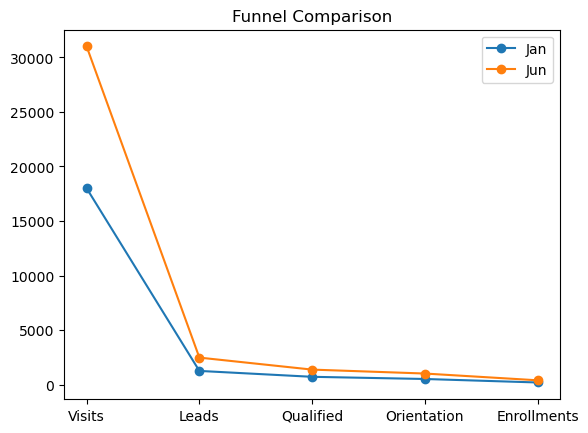

In [11]:
#Create Funnel Chart
funnel = ["Visits","Leads","Qualified","Orientation","Enrollments"]

jan = df.iloc[0][funnel]
jun = df.iloc[5][funnel]

plt.figure()
plt.plot(funnel, jan, marker='o', label="Jan")
plt.plot(funnel, jun, marker='o', label="Jun")
plt.title("Funnel Comparison")
plt.legend()
plt.show()

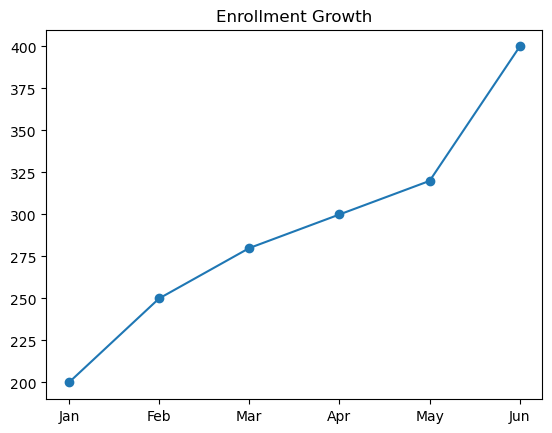

In [13]:
#2.MoM Growth
df["Enrollment_MoM"] = df["Enrollments"].pct_change()*100
df["Revenue_MoM"] = df["Revenue"].pct_change()*100

plt.figure()
plt.plot(df["Month"], df["Enrollments"], marker="o")
plt.title("Enrollment Growth")
plt.show()

In [14]:
#3.Forecast (Moving Average)
forecast = df["Enrollments"].tail(3).mean()
print("Forecast July Enrollment:",forecast)

Forecast July Enrollment: 340.0


In [55]:
#4.Contribution Margin
df["Cost"] = df["Enrollments"]*3200
df["Contribution"] = df["Revenue"]-df["Cost"]
df["Margin%"] = ((df["Contribution"]/df["Revenue"])*100).round(1)

## Dataset B — Webinar Analysis

In [43]:
webinar = {
"Registrations":[2400,2700,3100,3600],
"Showups":[1140,1260,1420,1620],
"Watch":[26,28,31,33],
"Clicks":[310,360,420,510],
"Paid":[86,101,130,160]}

df_web = pd.DataFrame(webinar)

In [24]:
#5.Conversion
df_web["Reg_Show"] = df_web["Showups"]/df_web["Registrations"]
df_web["Show_Click"] = df_web["Clicks"]/df_web["Showups"]
df_web["Click_Paid"] = df_web["Paid"]/df_web["Clicks"]

In [19]:
#6.Correlation
corr = df_web["Watch"].corr(df_web["Paid"])
print("Correlation:",corr)

Correlation: 0.9907242139010197


In [22]:
#7.
webinar_cost = 90000
price = 1499
df_web["Cost_per_Paid"] = webinar_cost / df_web["Paid"]
df_web["Revenue"] = df_web["Paid"] * price
df_web["ROAS"] = df_web["Revenue"] / webinar_cost

df_web

,Registrations,Showups,Watch,Clicks,Paid,Reg_Show,Show_Click,Click_Paid,Cost_per_Paid,Revenue,ROAS
0,2400,1140,26,310,86,0.475000,0.271930,0.277419,1046.511628,128914,1.432378
1,2700,1260,28,360,101,0.466667,0.285714,0.280556,891.089109,151399,1.682211
2,3100,1420,31,420,130,0.458065,0.295775,0.309524,692.307692,194870,2.165222
3,3600,1620,33,510,160,0.450000,0.314815,0.313725,562.500000,239840,2.664889


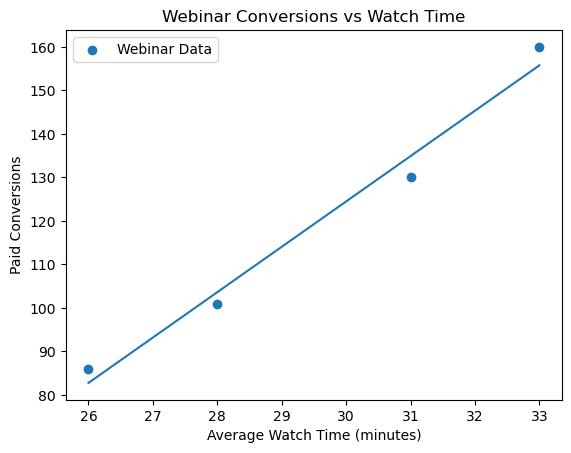

In [44]:
#Webinar Conversions vs Watch Time
import numpy as np
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df_web["Watch"], df_web["Paid"], label="Webinar Data")

# Trend line
z = np.polyfit(df_web["Watch"], df_web["Paid"], 1)
p = np.poly1d(z)

plt.plot(df_web["Watch"], p(df_web["Watch"]))
plt.xlabel("Average Watch Time (minutes)")
plt.ylabel("Paid Conversions")
plt.title("Webinar Conversions vs Watch Time")
plt.legend()
plt.show()

## Dataset C — Pricing A/B Test

In [25]:
data_c = {
"Variant":["A","B"],
"Visits":[12000,12300],
"Leads":[840,930],
"Enrollments":[210,246],
"Price":[14500,14500]}

df_c = pd.DataFrame(data_c)
df_c

,Variant,Visits,Leads,Enrollments,Price
0,A,12000,840,210,14500
1,B,12300,930,246,14500


In [26]:
#8.Visit-Enrollment Conversion Rate
df_c["Visit_to_Enroll"] = df_c["Enrollments"]/df_c["Visits"]
df_c

,Variant,Visits,Leads,Enrollments,Price,Visit_to_Enroll
0,A,12000,840,210,14500,0.0175
1,B,12300,930,246,14500,0.0200


In [27]:
#9.Lead-Enrollment Conversion
df_c["Lead_to_Enroll"] = df_c["Enrollments"]/df_c["Leads"]
df_c

,Variant,Visits,Leads,Enrollments,Price,Visit_to_Enroll,Lead_to_Enroll
0,A,12000,840,210,14500,0.0175,0.250000
1,B,12300,930,246,14500,0.0200,0.264516


In [28]:
# Two Proportion Z-Test
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

enrollments = np.array([210,246])
visits = np.array([12000,12300])

z_stat, p_value = proportions_ztest(enrollments, visits)

print("Z score:",z_stat)
print("P value:",p_value)

Z score: -1.4358674361335755
P value: 0.15104006616442556


## Decision
Since p-value < 0.05, we reject H0.
Variant B significantly improves conversion rate compared to Variant A.

# Dataset D — NPS Analysis

In [30]:
#Ratings Data Load
import pandas as pd
import numpy as np

ratings = [5,4,5,3,4,4,5,2,3,4,
           5,5,4,3,5,4,4,5,3,5,
           2,4,5,5,4,3,4,5,4,5]

df_ratings = pd.DataFrame(ratings, columns=["Ratings"])
df_ratings.head()

,Ratings
0,5
1,4
2,5
3,3
4,4


In [31]:
#10.Frequency Distribution
freq = df_ratings["Ratings"].value_counts().sort_index()
print(freq)

2     2
3     5
4    11
5    12
Name: Ratings, dtype: int64


In [32]:
#Mean, Median, Mode, Standard Deviation
mean_rating = df_ratings["Ratings"].mean()
median_rating = df_ratings["Ratings"].median()
mode_rating = df_ratings["Ratings"].mode()[0]
std_rating = df_ratings["Ratings"].std()

print("Mean:", mean_rating)
print("Median:", median_rating)
print("Mode:", mode_rating)
print("Standard Deviation:", std_rating)

Mean: 4.1
Median: 4.0
Mode: 5
Standard Deviation: 0.9228890171255886


In [33]:
#11.NPS Data
nps_scores = [10,9,8,7,10,6,9,8,9,10,
              5,6,7,8,9,9,4,10,8,9,
              10,3,9,8,7,10,9,6,8,9,
              10,8,9,7,6,9,8,10,9,8]

df_nps = pd.DataFrame(nps_scores, columns=["Score"])

In [34]:
#Promoters / Passives / Detractors
promoters = df_nps[df_nps["Score"] >= 9].count()[0]
passives = df_nps[(df_nps["Score"] >= 7) & (df_nps["Score"] <= 8)].count()[0]
detractors = df_nps[df_nps["Score"] <= 6].count()[0]

total = len(df_nps)

In [35]:
#NPS Score Calculation
nps_score = ((promoters/total) - (detractors/total))*100
print("NPS Score:", nps_score)

NPS Score: 32.5


In [36]:
#90% Confidence Interval
p = (promoters - detractors) / total
se = np.sqrt((1 - p**2)/total)
z = 1.645  # for 90% CI

lower = (p - z*se)*100
upper = (p + z*se)*100
print("90% Confidence Interval:", lower, "to", upper)

90% Confidence Interval: 7.902230236386265 to 57.09776976361374


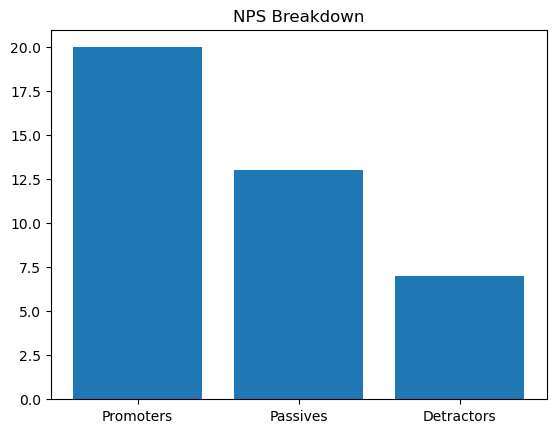

In [42]:
#NPS Chart
import matplotlib.pyplot as plt

labels = ["Promoters","Passives","Detractors"]
values = [promoters, passives, detractors]

plt.figure()
plt.bar(labels, values)
plt.title("NPS Breakdown")
plt.show()

12. Answer

Action 1:

Improve mentorship sessions because some students rated 3 or lower.

Action 2:

Increase engagement activities (weekly Q&A / doubt sessions) to convert passives into promoters.

## Dataset E — B2B College Outreach 


In [38]:
import pandas as pd

data_e = {"Month":["May","Jun","Jul"],
"Emails":[900,1100,1300],
"Replies":[72,77,91],
"Meetings":[24,28,30],
"MoU":[3,4,5],
"Seats":[240,360,420],
"Realization_Rate":[0.70,0.65,0.68]}

df_e = pd.DataFrame(data_e)
df_e

,Month,Emails,Replies,Meetings,MoU,Seats,Realization_Rate
0,May,900,72,24,3,240,0.70
1,Jun,1100,77,28,4,360,0.65
2,Jul,1300,91,30,5,420,0.68


In [39]:
#13.Stage-wise Conversion Rates
df_e["Email_to_Reply"] = df_e["Replies"] / df_e["Emails"]
df_e["Reply_to_Meeting"] = df_e["Meetings"] / df_e["Replies"]
df_e["Meeting_to_MoU"] = df_e["MoU"] / df_e["Meetings"]
df_e

,Month,Emails,Replies,Meetings,MoU,Seats,Realization_Rate,Email_to_Reply,Reply_to_Meeting,Meeting_to_MoU
0,May,900,72,24,3,240,0.70,0.08,0.333333,0.125000
1,Jun,1100,77,28,4,360,0.65,0.07,0.363636,0.142857
2,Jul,1300,91,30,5,420,0.68,0.07,0.329670,0.166667


In [40]:
#Biggest Drop-off Stage
conversion_cols = ["Email_to_Reply","Reply_to_Meeting","Meeting_to_MoU"]
df_e[conversion_cols].mean()

Email_to_Reply      0.073333
Reply_to_Meeting    0.342213
Meeting_to_MoU      0.144841
dtype: float64

In [41]:
#14.Expected Realized Seats
df_e["Expected_Seats"] = df_e["Seats"] * df_e["Realization_Rate"]
df_e

,Month,Emails,Replies,Meetings,MoU,Seats,Realization_Rate,Email_to_Reply,Reply_to_Meeting,Meeting_to_MoU,Expected_Seats
0,May,900,72,24,3,240,0.70,0.08,0.333333,0.125000,168.0
1,Jun,1100,77,28,4,360,0.65,0.07,0.363636,0.142857,234.0
2,Jul,1300,91,30,5,420,0.68,0.07,0.329670,0.166667,285.6


## Dataset F — LMS Engagement & Retention

In [45]:
import pandas as pd

data_f = {
"Week":[1,2,3,4],
"Active_Users":[400,385,360,335],
"Avg_Sessions":[3.2,3.0,2.8,2.6],
"Avg_Minutes":[24,23,22,21],
"Assignments":[380,360,340,320]}

df_f = pd.DataFrame(data_f)
df_f

,Week,Active_Users,Avg_Sessions,Avg_Minutes,Assignments
0,1,400,3.2,24,380
1,2,385,3.0,23,360
2,3,360,2.8,22,340
3,4,335,2.6,21,320


In [47]:
#15.Retention % and Churn Rate
retention = (df_f["Active_Users"].iloc[-1] / df_f["Active_Users"].iloc[0]) * 100
churn = 100 - retention

print("Retention %:", round(retention,1))
print("Churn Rate %:", round(churn,1))

Retention %: 83.8
Churn Rate %: 16.2


In [48]:
#16.Regression (Minutes ~ Week)
from sklearn.linear_model import LinearRegression
import numpy as np

X = df_f[["Week"]]
y = df_f["Avg_Minutes"]

model = LinearRegression()
model.fit(X,y)
slope = model.coef_[0]
r2 = model.score(X,y)
print("Slope:", slope)
print("R²:", r2)

Slope: -1.0
R²: 1.0


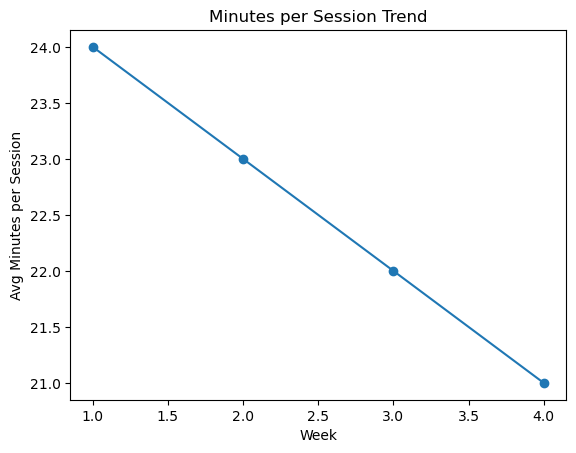

In [49]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df_f["Week"], df_f["Avg_Minutes"], marker='o')

plt.xlabel("Week")
plt.ylabel("Avg Minutes per Session")
plt.title("Minutes per Session Trend")
plt.show()

17.Intervention

Insight:
    
Average minutes per session decreases from 24 minutes (W1) to 21 minutes (W4), showing declining engagement.

Intervention:
    
Introduce weekly mentor live sessions or project-based activities in Week 2–3 to maintain engagement and prevent drop-off.

## Short Answer (Concepts in the My Equation Context)

### 1. When enrollment revenue grows faster than enrollments, what statistical/operational explanations could fit our context?

Explanation 1: Higher priced programs
If revenue increases faster than enrollments, it could mean that more students are enrolling in higher-priced programs such as advanced AI or specialization courses.

Validation Metric:
Average Revenue Per Enrollment (ARPU)

Explanation 2: Price increase or upselling
The company may have increased course prices or successfully upsold add-on services like mentorship or certifications.

Validation Metric:
Average Course Price per Enrollment

### 2. In highly skewed lead quality distributions, which central tendency would you report to leadership?

I would report the **median**.

Reason:
In skewed distributions, the mean can be affected by extreme values (very high or very low lead scores). The median represents the middle value and gives a more reliable measure of typical lead quality.

### 3. Minimal pre-post experiment to test mentor AMA impact

Step 1: Pre-test
Measure Orientation → Enrollment conversion rate for a cohort without the mentor AMA.

Step 2: Intervention
Add a 30-minute mentor AMA session during orientation.

Step 3: Post-test
Measure the Orientation → Enrollment conversion rate for the new cohort.

Step 4: Compare Results
If the conversion rate increases significantly after introducing the AMA, it suggests the intervention improved enrollment conversion.

## Charts Section

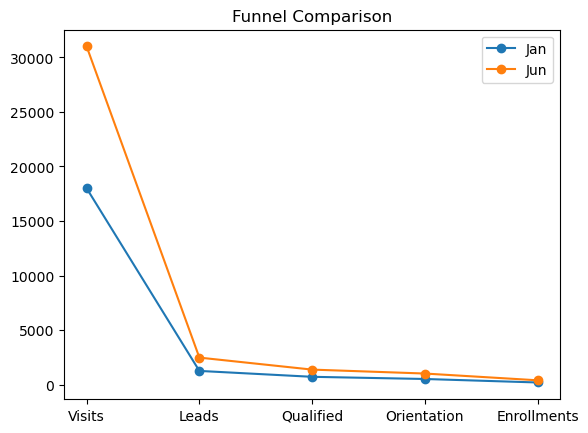

In [50]:
#Create Funnel Chart
funnel = ["Visits","Leads","Qualified","Orientation","Enrollments"]

jan = df.iloc[0][funnel]
jun = df.iloc[5][funnel]

plt.figure()
plt.plot(funnel, jan, marker='o', label="Jan")
plt.plot(funnel, jun, marker='o', label="Jun")
plt.title("Funnel Comparison")
plt.legend()
plt.show()

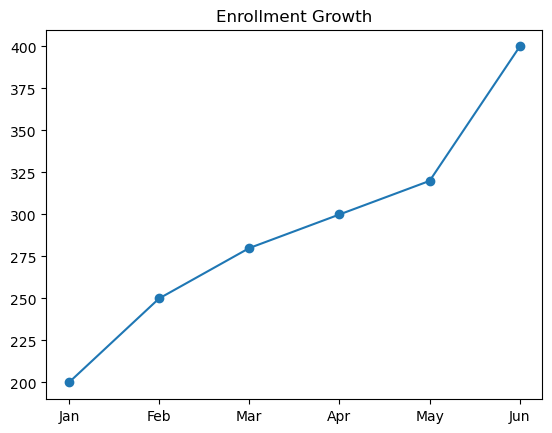

In [51]:
#MoM Growth
df["Enrollment_MoM"] = df["Enrollments"].pct_change()*100
df["Revenue_MoM"] = df["Revenue"].pct_change()*100

plt.figure()
plt.plot(df["Month"], df["Enrollments"], marker="o")
plt.title("Enrollment Growth")
plt.show()

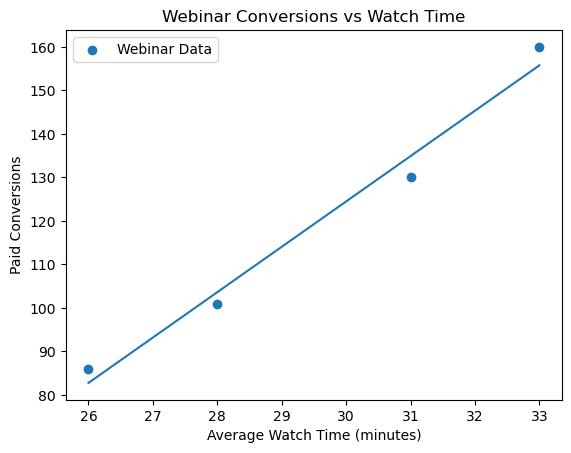

In [52]:
#Webinar Conversions vs Watch Time
import numpy as np
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df_web["Watch"], df_web["Paid"], label="Webinar Data")

# Trend line
z = np.polyfit(df_web["Watch"], df_web["Paid"], 1)
p = np.poly1d(z)

plt.plot(df_web["Watch"], p(df_web["Watch"]))
plt.xlabel("Average Watch Time (minutes)")
plt.ylabel("Paid Conversions")
plt.title("Webinar Conversions vs Watch Time")
plt.legend()
plt.show()

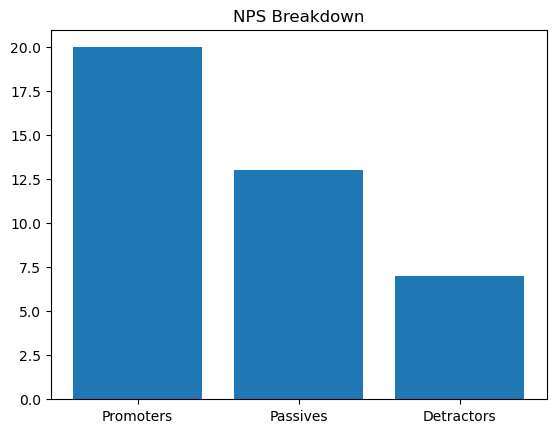

In [53]:
#NPS Chart
import matplotlib.pyplot as plt

labels = ["Promoters","Passives","Detractors"]
values = [promoters, passives, detractors]

plt.figure()
plt.bar(labels, values)
plt.title("NPS Breakdown")
plt.show()